In [2]:
from pathlib import Path
import pickle
import sys
import os
sys.path.append('../')

DATA_DIR = Path('../data/100000_data_points')
DATA_PATH = DATA_DIR / "synthetic_rl_datasets.pkl"
try:
    with open(DATA_PATH, 'rb') as f:
        all_data = pickle.load(f)
except FileNotFoundError:
    print(f"File not found: {DATA_PATH}")
except Exception as e:
    print(f"Error loading dataset: {e}")


In [3]:
import random
import numpy as np
import sys
import torch
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

sys.path.append('../')
# Add the root directory to the Python path to find your modules

from models.reward_cnn import RewardCNNCentralized
from tests.cnn.centralized.generate_synthetic_states import (
    generate_synthetic_state_at_most_1_apples,
)
from config import MODEL_DIR, GRAPHS_DIR
import torch
from tests.cnn.centralized.generate_synthetic_states import (
    generate_synthetic_state_at_most_1_apples,
)
from train_scripts.train_centralized_cnn import MODEL_SAVE_PATH
import matplotlib.pyplot as plt
from config import GRAPHS_DIR, OUT_DIR
from tqdm import tqdm


keys=list(all_data.keys())
keys = [keys[0]]
hidden_dim = [8, 32, 64, 256]
hidden_dim = [8]
print(f"Available keys in dataset: {keys}")
p_pick_apple = 0.5


--- PyTorch is configured to use: cuda ---
Available keys in dataset: ['6x6_2_agents']


--------------Processing key: 6x6_2_agents --------------
--- Hidden features: 8 ---
100000
{'state': {'apples': array([[1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], dtype=int8), 'agents': array([[1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], dtype=int8)}, 'agent_pos': (np.int64(0), np.int64(0)), 'reward': 1}
<class 'models.reward_network.RewardNetwork'>


Training: 100%|██████████| 1000/1000 [00:05<00:00, 171.36it/s]


Final loss after training: 0.22644089968288816


✓ Accuracies saved to /home/glyst/code/orchard-action-market/out/mlp_decentralized_accuracies_1acting_6x6_2_agents.txt  with accuracies: [0.00775]


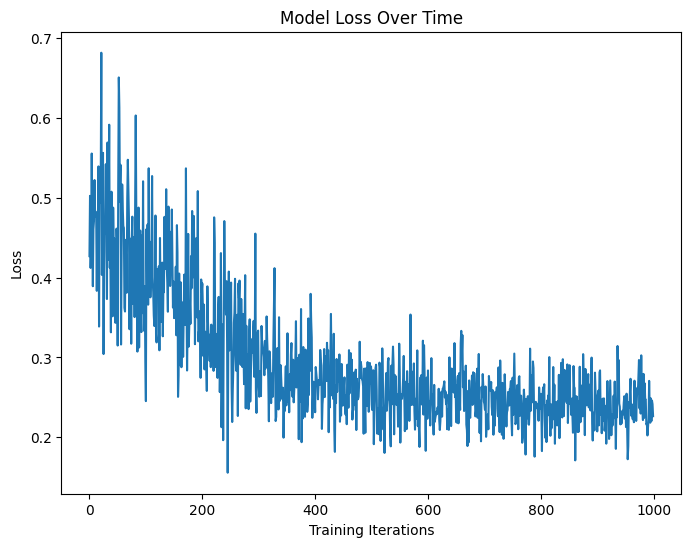

In [ ]:
import json
from models.reward_network import RewardNetwork
from helpers.controllers import ViewController
from decentralized_helpers import generate_reward_vector, pick_agent_uniformly, get_agent_positions
# HERE AGENT 0 ALWAYS PICKS UP THE APPLE

# MLP experiments, 1 agent acting
NUM_ACTING_AGENTS = 1


viewController = ViewController(vision=0, new_input=True)
def processed_state(state, agent_pos):
    return viewController.state_to_nn_input(state, agent_pos, None)

for key in keys:
    accuracies = []
    print(f"--------------Processing key: {key} --------------")
    for hidden in hidden_dim:
        print(f"--- Hidden features: {hidden} ---")
        data = all_data[key]

        NUM_DATA_POINTS = 100000


        num_picks_apple = int(NUM_DATA_POINTS * p_pick_apple)
        num_no_picks_apple = NUM_DATA_POINTS - num_picks_apple

        data_with_apple = data['picks_apple'][:num_picks_apple]
        data_without_apple = data['doesnt_pick_apple'][:num_no_picks_apple]

        state_agentpos_reward = data_with_apple + data_without_apple
        random.shuffle(state_agentpos_reward)
        print(len(state_agentpos_reward))
        print(state_agentpos_reward[0])

        NUM_TRAIN_EPISODES = 1000
        percent_train = 0.8
        total_train = int(0.8 * NUM_DATA_POINTS)
        state_agentpos_reward_TRAIN = state_agentpos_reward[:total_train]
        state_agentpos_reward_TEST = state_agentpos_reward[total_train:]
        if key == '6x6_2_agents':
            WIDTH = 6
            HEIGHT = 6
            NUM_AGENTS = 2
        elif key == '9x9_4_agents':
            WIDTH = 9
            HEIGHT = 9
            NUM_AGENTS = 4
        elif key == '12x12_7_agents':
            WIDTH = 12
            HEIGHT = 12
            NUM_AGENTS = 7
        else:
            raise ValueError(f"Unknown key: {key}")
        BATCH_SIZE = 32
        lr = 0.0001

        # we use a list of networks instead of one
        networks = []

        for _ in range(NUM_AGENTS):
            networks.append(RewardNetwork(WIDTH * HEIGHT * 3, 1, lr, 0.99, hidden, 4))
        print(type(networks[0]))

        for i in tqdm(range(NUM_TRAIN_EPISODES), desc="Training"):
            for b in range(BATCH_SIZE):
                row_index = i * BATCH_SIZE + b

                # Pick the constant that represents how many acting agents we have. In the first setup, it's always agent with id 0.
                picker_id = pick_agent_uniformly(NUM_ACTING_AGENTS)

                assert(picker_id == 0)

                # We know that apple and agent are in the same cell if the apple is picked
                apple_pos = state_agentpos_reward_TRAIN[row_index]["agent_pos"]


                agent_positions = get_agent_positions(state_agentpos_reward_TRAIN[row_index]["state"]["agents"],
                                                      state_agentpos_reward_TRAIN[row_index]["agent_pos"], picker_id)

                picked =  state_agentpos_reward_TRAIN[row_index]["reward"] != 0

                assert np.array_equal(agent_positions[picker_id], apple_pos)
                reward_vector = generate_reward_vector(picker_id, agent_positions, apple_pos, picked)
                if picked:
                    assert(reward_vector[picker_id] == -1)
                    sum_ = 0
                    for r in reward_vector:
                        if r != -1:
                            sum_ += r

                    # check with tolerance
                    assert np.isclose(sum_, 2.0, atol=1e-8)
                else:
                    assert(reward_vector[picker_id] == 0)

                state = state_agentpos_reward_TRAIN[row_index]["state"]

                for a in range(NUM_AGENTS):
                    reward = reward_vector[a]
                    position = agent_positions[a]
                    networks[a].add_experience(processed_state(state, position), reward)

            for model in networks:
                model.train()

        model = networks[0]
        print(f"Final loss after training: {model.loss_history[-1]}")

        plt.figure(figsize=(8, 6))
        plt.plot(model.loss_history)
        plt.xlabel("Training Iterations")
        plt.ylabel("Loss")
        plt.title("Model Loss Over Time")
        plt.savefig(GRAPHS_DIR / f"mlp_decentralized_1acting_loss_{key}_{hidden}h.png")


        
        ######################### TEST LOOP #########################
        num_test_episodes = len(state_agentpos_reward_TEST)
        num_correct = 0
        num_correct_when_reward_negative = 0
        num_correct_when_reward_0 = 0
        num_correct_when_reward_positive = 0
        num_negative_predictions = 0
        num_zero_predictions = 0
        num_positive_predictions = 0
        tol = 10e-2
        for i in tqdm(range(num_test_episodes), leave=False):
            picker_id = pick_agent_uniformly(NUM_ACTING_AGENTS)

            assert(picker_id == 0)

            # We know that apple and agent are in the same cell if the apple is picked
            apple_pos = state_agentpos_reward_TEST[i]["agent_pos"]

            agent_positions = get_agent_positions(state_agentpos_reward_TEST[i]["state"]["agents"],
                                                  state_agentpos_reward_TEST[i]["agent_pos"], picker_id)

            picked =  state_agentpos_reward_TEST[i]["reward"] != 0

            assert np.array_equal(agent_positions[picker_id], apple_pos)
            reward_vector = generate_reward_vector(picker_id, agent_positions, apple_pos, picked)
            if picked:
                assert(reward_vector[picker_id] == -1)
                sum_ = 0
                for r in reward_vector:
                    if r != -1:
                        sum_ += r
                # check with tolerance
                assert np.isclose(sum_, 2.0, atol=1e-8)
            else:
                assert(reward_vector[picker_id] == 0)

            state = state_agentpos_reward_TEST[i]["state"]
            for a in range(NUM_AGENTS):
                reward = reward_vector[a]
                position = agent_positions[a]
                prediction = networks[a].get_model_reward_prediction(processed_state(state, position)).item()
                error = abs(prediction - reward)
                if error < tol:
                    num_correct += 1

        accuracy = num_correct / (num_test_episodes * NUM_AGENTS)
        accuracies.append(accuracy)
        # save the accuracies for this key to a file as raw data
    filename = OUT_DIR / f"mlp_decentralized_accuracies_1acting_{key}.txt"
    try:
        with open(filename, "w") as f:
            json.dump(accuracies, f, indent=4)
        print("✓ Accuracies saved to", filename, " with accuracies:", accuracies)
    except Exception as e:
        print("Error saving accuracies:", e)


--------------Processing key: 6x6_2_agents --------------
--- Hidden features: 8 ---
100000
{'state': {'apples': array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 1, 0, 0, 0]], dtype=int8), 'agents': array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0]], dtype=int8)}, 'agent_pos': (np.int64(4), np.int64(4)), 'reward': 1}
<class 'models.reward_network.RewardNetwork'>


Training: 100%|██████████| 1000/1000 [00:06<00:00, 151.77it/s]


Final loss after training: 0.9538646229747709


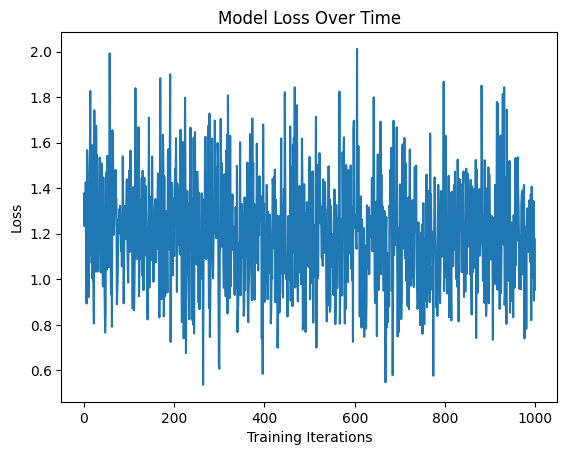

In [ ]:
import json
from models.reward_network import RewardNetwork
from helpers.controllers import ViewController
from decentralized_helpers import generate_reward_vector, pick_agent_uniformly, get_agent_positions

# MLP experiments, all agents acting

viewController = ViewController(vision=0, new_input=True)
def processed_state(state, agent_pos):
    return viewController.state_to_nn_input(state, agent_pos, None)

for key in keys:
    accuracies = []
    print(f"--------------Processing key: {key} --------------")
    for hidden in hidden_dim:
        print(f"--- Hidden features: {hidden} ---")
        data = all_data[key]

        NUM_DATA_POINTS = 100000


        num_picks_apple = int(NUM_DATA_POINTS * p_pick_apple)
        num_no_picks_apple = NUM_DATA_POINTS - num_picks_apple

        data_with_apple = data['picks_apple'][:num_picks_apple]
        data_without_apple = data['doesnt_pick_apple'][:num_no_picks_apple]

        state_agentpos_reward = data_with_apple + data_without_apple
        random.shuffle(state_agentpos_reward)
        print(len(state_agentpos_reward))
        print(state_agentpos_reward[0])

        NUM_TRAIN_EPISODES = 1000
        percent_train = 0.8
        total_train = int(0.8 * NUM_DATA_POINTS)
        state_agentpos_reward_TRAIN = state_agentpos_reward[:total_train]
        state_agentpos_reward_TEST = state_agentpos_reward[total_train:]
        if key == '6x6_2_agents':
            WIDTH = 6
            HEIGHT = 6
            NUM_AGENTS = 2
        elif key == '9x9_4_agents':
            WIDTH = 9
            HEIGHT = 9
            NUM_AGENTS = 4
        elif key == '12x12_7_agents':
            WIDTH = 12
            HEIGHT = 12
            NUM_AGENTS = 7
        else:
            raise ValueError(f"Unknown key: {key}")
        BATCH_SIZE = 32
        lr = 0.0001

        NUM_ACTING_AGENTS = NUM_AGENTS

        # we use a list of networks instead of one
        networks = []

        for _ in range(NUM_AGENTS):
            networks.append(RewardNetwork(WIDTH * HEIGHT * 3, 1, lr, 0.99, hidden, 4))
        print(type(networks[0]))

        for i in tqdm(range(NUM_TRAIN_EPISODES), desc="Training"):
            for b in range(BATCH_SIZE):
                row_index = i * BATCH_SIZE + b

                # Pick the constant that represents how many acting agents we have. In the first setup, it's always agent with id 0.
                picker_id = pick_agent_uniformly(NUM_ACTING_AGENTS)

                assert(picker_id < NUM_ACTING_AGENTS)

                # We know that apple and agent are in the same cell if the apple is picked
                apple_pos = state_agentpos_reward_TRAIN[row_index]["agent_pos"]


                agent_positions = get_agent_positions(state_agentpos_reward_TRAIN[row_index]["state"]["agents"],
                                                      state_agentpos_reward_TRAIN[row_index]["agent_pos"], picker_id)

                picked =  state_agentpos_reward_TRAIN[row_index]["reward"] != 0

                assert np.array_equal(agent_positions[picker_id], apple_pos)
                reward_vector = generate_reward_vector(picker_id, agent_positions, apple_pos, picked)
                if picked:
                    assert(reward_vector[picker_id] == -1)
                    sum_ = 0
                    for r in reward_vector:
                        if r != -1:
                            sum_ += r

                    # check with tolerance
                    assert np.isclose(sum_, 2.0, atol=1e-8)
                else:
                    assert(reward_vector[picker_id] == 0)

                state = state_agentpos_reward_TRAIN[row_index]["state"]

                for a in range(NUM_AGENTS):
                    reward = reward_vector[a]
                    position = agent_positions[a]
                    networks[a].add_experience(processed_state(state, position), reward)

            for model in networks:
                model.train()

        # EVERYTHING BELOW THIS IS SUBJECT TO CHANGE - COPIED FROM CENTRALIZED
        model = networks[0]
        print(f"Final loss after training: {model.loss_history[-1]}")

        # plot model loss
        plt.plot(model.loss_history)
        plt.xlabel("Training Iterations")
        plt.ylabel("Loss")
        plt.title("Model Loss Over Time")
        plt.savefig(GRAPHS_DIR / f"mlp_decentralized_loss_allActing_{key}_{hidden}h.png")


        # --- Configuration (should match the trained model) ---
        num_test_episodes = len(state_agentpos_reward_TEST)
        # --- Test Loop (no training here!) ---
        num_correct = 0
        num_correct_when_reward_negative = 0
        num_correct_when_reward_0 = 0
        num_correct_when_reward_positive = 0
        num_negative_predictions = 0
        num_zero_predictions = 0
        num_positive_predictions = 0
        tol = 10e-2
        for i in tqdm(range(num_test_episodes), leave=False):
            picker_id = pick_agent_uniformly(NUM_ACTING_AGENTS)

            assert(picker_id < NUM_ACTING_AGENTS)

            # We know that apple and agent are in the same cell if the apple is picked
            apple_pos = state_agentpos_reward_TEST[i]["agent_pos"]

            agent_positions = get_agent_positions(state_agentpos_reward_TEST[i]["state"]["agents"],
                                                  state_agentpos_reward_TEST[i]["agent_pos"], picker_id)

            picked =  state_agentpos_reward_TRAIN[i]["reward"] != 0

            assert np.array_equal(agent_positions[picker_id], apple_pos)
            reward_vector = generate_reward_vector(picker_id, agent_positions, apple_pos, picked)
            if picked:
                assert(reward_vector[picker_id] == -1)
                sum_ = 0
                for r in reward_vector:
                    if r != -1:
                        sum_ += r
                # check with tolerance
                assert np.isclose(sum_, 2.0, atol=1e-8)
            else:
                assert(reward_vector[picker_id] == 0)

            state = state_agentpos_reward_TEST[i]["state"]
            for a in range(NUM_AGENTS):
                reward = reward_vector[a]
                position = agent_positions[a]
                prediction = networks[a].get_model_reward_prediction(processed_state(state, position)).item()
                error = abs(prediction - reward)
                if error < tol:
                    num_correct += 1
                    if picked:
                        if a == picker_id:
                            num_correct_when_reward_negative += 1
                            num_negative_predictions += 1
                        else:
                            num_correct_when_reward_positive += 1
                            num_positive_predictions += 1

                    else:
                        num_correct_when_reward_0 += 1
                        num_zero_predictions += 1

        accuracy = num_correct / (num_test_episodes * NUM_AGENTS)
        accuracies.append(accuracy)
        # save the accuracies for this key to a file as raw data
    filename = OUT_DIR / f"mlp_decentralized_accuracies_allActing_{key}.txt"
    with open(filename, "w") as f:
        json.dump(accuracies, f, indent=4)
